In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

In [2]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0]
# 1 => [0 1 0]
# 2 => [0 0 1]

In [3]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]


In [4]:
model = keras.Sequential(
  [
    layers.Dense(3, activation="sigmoid", name="layer1", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer2"),
  ]
)

model.summary()

/opt/anaconda3/envs/mia/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
y = model(X)
print(y[149])

tf.Tensor([0.4815749  0.44665024 0.59440655], shape=(3,), dtype=float32)


In [6]:
optimizer=tf.keras.optimizers.SGD(learning_rate=0.03)
loss=tf.keras.losses.MeanSquaredError()

model.compile(optimizer, loss)
history = model.fit(X, Y, epochs=500)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2568 
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2560
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2552
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2544
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2536
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2528
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2521
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2513
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2506
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2499
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2492
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2486
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2479
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2473
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2467
Epoch 16/500
5/5 ━━━━━━━━━━━━━━━━

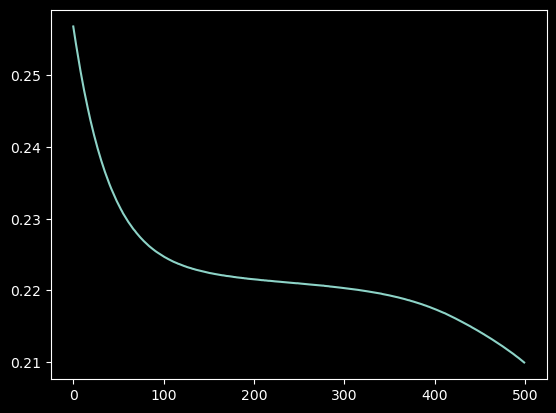

In [7]:
plt.plot(history.history['loss'])
plt.show()

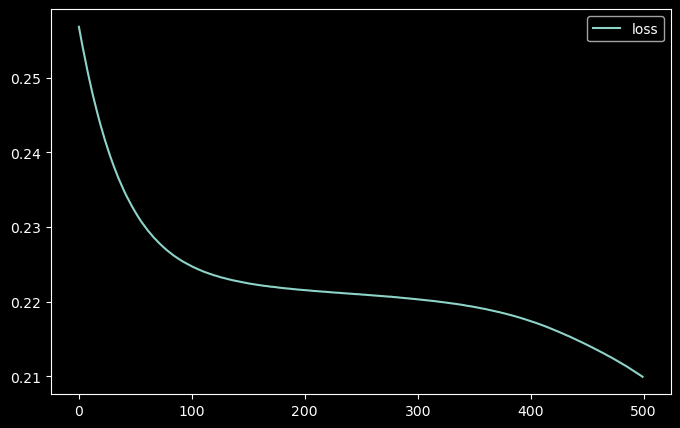

In [8]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

In [9]:
model.predict(np.array([[3,3,1,1]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


array([[0.42221555, 0.34940785, 0.3186774 ]], dtype=float32)

# Aqui empieza mi ejercicio para convertir la red neuronal a 4 X 3 X 3 X 3 X 3

In [10]:
model = keras.Sequential(
  [
    layers.Dense(4, activation="sigmoid", name="input", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer2"),
    layers.Dense(3, activation="sigmoid", name="layer3"),
    layers.Dense(3, activation="sigmoid", name="layer4"),
    layers.Dense(3, activation="sigmoid", name="output"),
  ]
)

model.summary()

/opt/anaconda3/envs/mia/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (Dense)                   │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71 (284.00 B)

 Trainable params: 71 (284.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
y = model(X)
print(y[149])

tf.Tensor([0.7162911  0.54066664 0.4987192 ], shape=(3,), dtype=float32)


In [13]:
optimizer=tf.keras.optimizers.SGD(learning_rate=0.03)
loss=tf.keras.losses.MeanSquaredError()

model.compile(optimizer, loss)
history = model.fit(X, Y, epochs=500)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2941  
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2928
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2914
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2901
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2887
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2875
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2862
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2849
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2837
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2825
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2813
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2801
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2789
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2777
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2766
Epoch 16/500
5/5 ━━━━━━━━━━━━━━━

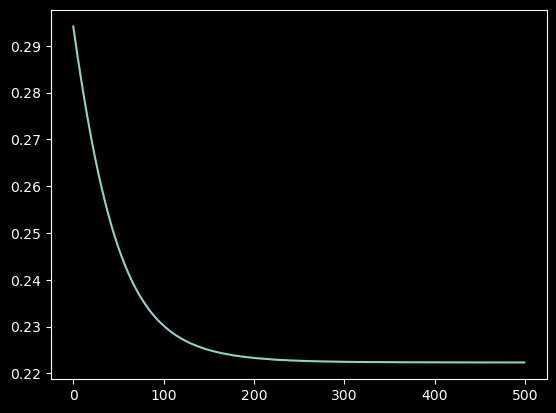

In [14]:
plt.plot(history.history['loss'])
plt.show()

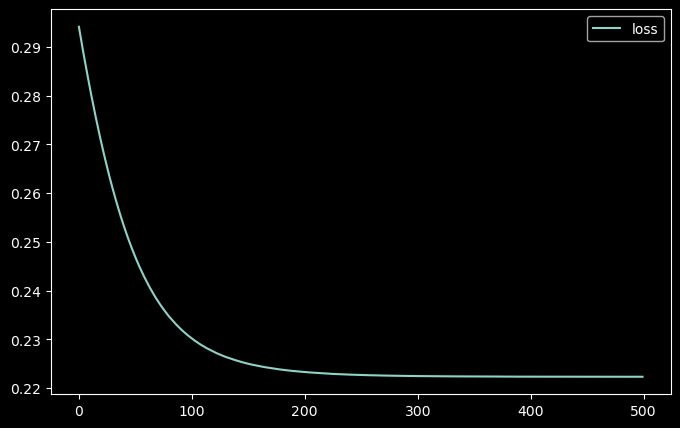

In [15]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

In [16]:
model.predict(np.array([[3,3,1,1]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


array([[0.3354092 , 0.33571506, 0.33457398]], dtype=float32)